# OPTICS Clustering (Ordering Points To Identify the Clustering Structure):
Is a density-based clustering algorithm similar to DBSCAN but more versatile. It is particularly useful when clusters have varying densities, which DBSCAN struggles with.


# Key Concepts
Core Distance: The minimum radius required for a point to be considered a core point (having at least min_samples within eps).

Reachability Distance: The minimum distance needed to reach a point from another core point.

Ordering of Points: OPTICS orders points based on their reachability distance, forming a hierarchical structure.

Cluster Extraction: Unlike DBSCAN, OPTICS does not explicitly assign clusters but creates a reachability plot from which clusters can be extracted at different density levels.

# Advantages
Works well with clusters of varying densities.
Does not require a strict eps parameter like DBSCAN.
Can detect hierarchical clustering structures.

# Implementation in Python (Using Scikit-Learn)


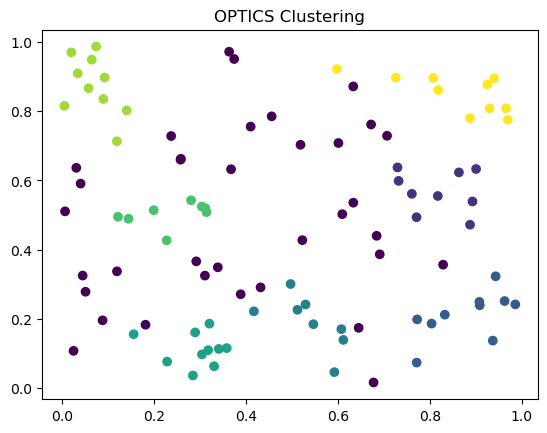

In [1]:
# necessary libraries
from sklearn.cluster import OPTICS
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.rand(100, 2)  # 100 points in 2D

# Apply OPTICS clustering
optics = OPTICS(min_samples=5,xi=0.05,min_cluster_size=0.05)
labels = optics.fit_predict(X)

# Plot results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.title("OPTICS Clustering")
plt.show()

# OPTICS on a Real-World Dataset
We'll use the Mall Customers dataset, which contains customer spending scores.

I'll fetch the dataset and implement OPTICS.

## Steps Covered in the Code:
Load the dataset (Mall Customers dataset)

Preprocess the data (select relevant features, scale data)

Apply OPTICS for clustering

Visualize the results

C:\Users\franc\AppData\Local\Temp\ipykernel_9408\1273249145.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X.fillna(method='ffill', inplace=True)


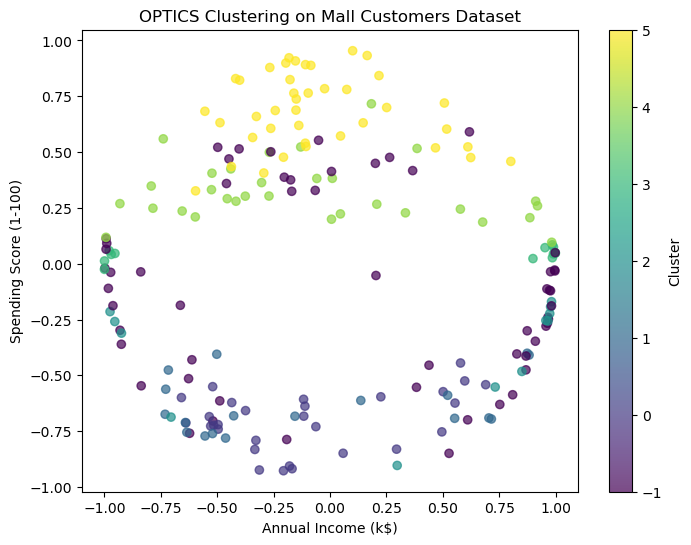

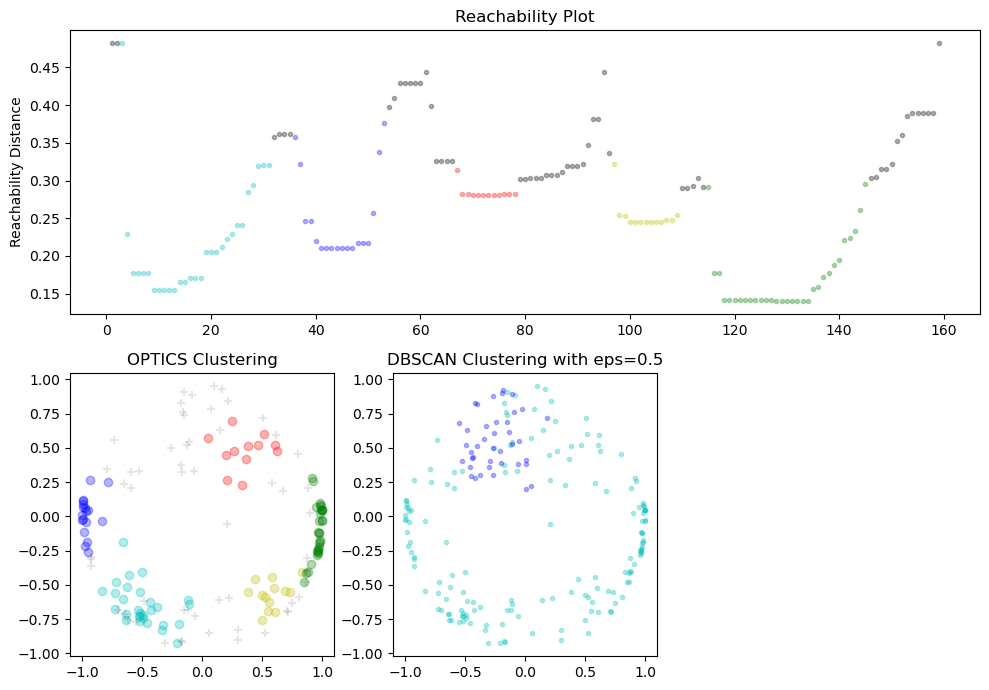

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import OPTICS, cluster_optics_dbscan
from sklearn.preprocessing import StandardScaler, normalize

# Load dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\Mall_Customers.csv")

# Drop irrelevant columns
drop_features = ['CustomerID', 'Gender']
X = df.drop(drop_features, axis=1)

# Handle missing values
X.fillna(method='ffill', inplace=True)

# Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_normalized = normalize(X_scaled)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

# OPTICS Model
optics_model = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
optics_model.fit(X_normalized)

# Extract labels using DBSCAN technique with eps = 0.5
labels_dbscan = cluster_optics_dbscan(reachability=optics_model.reachability_,
                                      core_distances=optics_model.core_distances_,
                                      ordering=optics_model.ordering_, eps=0.5)

# Reachability and cluster labels
space = np.arange(len(X_normalized))
reachability = optics_model.reachability_[optics_model.ordering_]
labels_optics = optics_model.labels_[optics_model.ordering_]

# Scatter plot for OPTICS clustering
plt.figure(figsize=(8, 6))
plt.scatter(X_normalized.iloc[:, 0], X_normalized.iloc[:, 1], c=labels_optics, cmap='viridis', marker='o', alpha=0.7)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("OPTICS Clustering on Mall Customers Dataset")
plt.colorbar(label="Cluster")
plt.show()

# Visualization framework
plt.figure(figsize=(10, 7))
G = gridspec.GridSpec(2, 3)
ax1 = plt.subplot(G[0, :])
ax2 = plt.subplot(G[1, 0])
ax3 = plt.subplot(G[1, 1])

# Reachability-Distance Plot
colors = ['c.', 'b.', 'r.', 'y.', 'g.']
for Class, colour in zip(range(0, 5), colors):
    Xk = space[labels_optics == Class]
    Rk = reachability[labels_optics == Class]
    ax1.plot(Xk, Rk, colour, alpha=0.3)
ax1.plot(space[labels_optics == -1], reachability[labels_optics == -1], 'k.', alpha=0.3)
ax1.set_ylabel('Reachability Distance')
ax1.set_title('Reachability Plot')

# OPTICS Clustering Plot
for Class, colour in zip(range(0, 5), ['c', 'b', 'r', 'y', 'g']):  # Fix: Removed dot in color names
    Xk = X_normalized.iloc[optics_model.labels_ == Class]
    ax2.scatter(Xk.iloc[:, 0], Xk.iloc[:, 1], color=colour, alpha=0.3)  # Fix: Replaced 'c' with 'color'
ax2.scatter(X_normalized.iloc[optics_model.labels_ == -1, 0], 
            X_normalized.iloc[optics_model.labels_ == -1, 1], 
            color='k', marker='+', alpha=0.1)
ax2.set_title('OPTICS Clustering')

# DBSCAN Clustering Plot
for Class, colour in zip(range(0, 6), ['c', 'b', 'r', 'y', 'g', 'greenyellow']):  # Fix: Removed dot
    Xk = X_normalized.iloc[labels_dbscan == Class]
    ax3.scatter(Xk.iloc[:, 0], Xk.iloc[:, 1], color=colour, alpha=0.3, marker='.')  # Fix: Used 'color'
ax3.scatter(X_normalized.iloc[labels_dbscan == -1, 0], 
            X_normalized.iloc[labels_dbscan == -1, 1], 
            color='k', marker='+', alpha=0.1)
ax3.set_title('DBSCAN Clustering with eps=0.5')


plt.tight_layout()
plt.show()


# Core Concepts
OPTICS builds a reachability plot by processing data points in a structured way. The key terms involved are:

## Core Distance:

The minimum radius (distance) required for a point to be a core point (i.e., have at least min_samples neighbors within eps).

If a point doesn't meet this requirement, its core distance is undefined (∞).

## Reachability Distance:

The minimum distance needed to reach a point from another core point.

Defined as:

reachability(p,o) = max(core_dist(p),dist(p,o))

Ensures that points inside dense clusters have small reachability distances, while noise points have high reachability distances.

## Ordering of Points:

The algorithm orders points based on their reachability distances.

This ordering forms the OPTICS reachability plot, which is useful for extracting clusters at different density levels.

# Step-by-Step Algorithm
Select a point randomly and check if it is a core point.

Expand clusters by iterating through the nearest neighbors of the core point.

Order points by maintaining a priority queue of reachability distances.

Continue until all points are processed, creating an ordered list of points with their reachability distances.

Extract clusters from the reachability plot by choosing different threshold levels.


#  Visualizing the Reachability Plot
Once the reachability distances are computed, they can be plotted. Dense clusters appear as valleys, while sparse regions (noise) appear as peaks.

Valleys = Dense clusters

Peaks = Noise points or cluster boundaries

Clusters can be extracted by setting different density thresholds.

